In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importando os dados

Este conjunto de dados contém informações sobre os membros do Vingadores da Marvel. Cada entrada no conjunto de dados inclui detalhes como o nome ou alias do personagem, número de apariações, gênero, data de entrada na equipe dos Vingadores, status atual, e informações sobre possíveis mortes e retornos

In [4]:
df = pd.read_csv('../data/avengers.csv', encoding='ISO-8859-1')
df.head()

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,NaN,Sep-63,1963,52,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Merged with Ultron in Rage of Ultron Vol. 1. A...
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Secret Invasion V1:I8. Actually was se...
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Death: ""Later while under the influence of Imm..."
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dies in Ghosts of the Future arc. However ""he ..."
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Fear Itself brought back because that'...


## 2. Análise Exploratória de Dados

In [5]:
df.dtypes

URL                              str
Name/Alias                       str
Appearances                    int64
Current?                         str
Gender                           str
Probationary Introl              str
Full/Reserve Avengers Intro      str
Year                           int64
Years since joining            int64
Honorary                         str
Death1                           str
Return1                          str
Death2                           str
Return2                          str
Death3                           str
Return3                          str
Death4                           str
Return4                          str
Death5                           str
Return5                          str
Notes                            str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   URL                          173 non-null    str  
 1   Name/Alias                   163 non-null    str  
 2   Appearances                  173 non-null    int64
 3   Current?                     173 non-null    str  
 4   Gender                       173 non-null    str  
 5   Probationary Introl          15 non-null     str  
 6   Full/Reserve Avengers Intro  159 non-null    str  
 7   Year                         173 non-null    int64
 8   Years since joining          173 non-null    int64
 9   Honorary                     173 non-null    str  
 10  Death1                       173 non-null    str  
 11  Return1                      69 non-null     str  
 12  Death2                       17 non-null     str  
 13  Return2                      16 non-null     str  
 14  Death

Prenchendo os valores faltantes da coluna 'Return1' com 'NO'

In [7]:
df.fillna({'Return1': 'NO'}, inplace=True)

,URL,Name/Alias,Appearances,Current?,Gender,Probationary Introl,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,...,Return1,Death2,Return2,Death3,Return3,Death4,Return4,Death5,Return5,Notes
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,NaN,Sep-63,1963,52,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Merged with Ultron in Rage of Ultron Vol. 1. A...
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Secret Invasion V1:I8. Actually was se...
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Death: ""Later while under the influence of Imm..."
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dies in Ghosts of the Future arc. However ""he ..."
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,NaN,Sep-63,1963,52,Full,...,YES,YES,NO,NaN,NaN,NaN,NaN,NaN,NaN,Dies in Fear Itself brought back because that'...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,http://marvel.wikia.com/Eric_Brooks_(Earth-616)#,Eric Brooks,198,YES,MALE,NaN,13-Nov,2013,2,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,http://marvel.wikia.com/Adam_Brashear_(Earth-6...,Adam Brashear,29,YES,MALE,NaN,14-Jan,2014,1,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,http://marvel.wikia.com/Victor_Alvarez_(Earth-...,Victor Alvarez,45,YES,MALE,NaN,14-Jan,2014,1,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,http://marvel.wikia.com/Ava_Ayala_(Earth-616)#,Ava Ayala,49,YES,FEMALE,NaN,14-Jan,2014,1,Full,...,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Convertendo os valores das colunas 'Death1' e 'Return1' para valores numéricos, sendo 1, quando o texto for 'YES', e 0, quando o texto for 'NO'.

In [8]:
df['Death1'] = df['Death1'].replace({'YES': 1, 'NO': 0})

In [9]:
df['Return1'] = df['Return1'].replace({'YES': 1, 'NO': 0})

Cálculo da porcentagem de valores nulos por coluna

In [10]:
total_nulos = df.isnull().sum()
total_linhas = len(df)
porcentagem = (total_nulos / total_linhas) * 100
porcentagem

URL                             0.000000
Name/Alias                      5.780347
Appearances                     0.000000
Current?                        0.000000
Gender                          0.000000
Probationary Introl            91.329480
Full/Reserve Avengers Intro     8.092486
Year                            0.000000
Years since joining             0.000000
Honorary                        0.000000
Death1                          0.000000
Return1                         0.000000
Death2                         90.173410
Return2                        90.751445
Death3                         98.843931
Return3                        98.843931
Death4                         99.421965
Return4                        99.421965
Death5                         99.421965
Return5                        99.421965
Notes                          56.647399
dtype: float64

Removendo as colunas com valores nulos maiores que 10% da coluna

In [11]:
df = df.drop(['Probationary Introl','Death2', 'Return2', 'Death3',
              'Return3', 'Death4', 'Return4', 'Death5', 'Return5',
              'Notes'], axis=1)

In [12]:
df.head()

,URL,Name/Alias,Appearances,Current?,Gender,Full/Reserve Avengers Intro,Year,Years since joining,Honorary,Death1,Return1
0,http://marvel.wikia.com/Henry_Pym_(Earth-616),"Henry Jonathan ""Hank"" Pym",1269,YES,MALE,Sep-63,1963,52,Full,1,0
1,http://marvel.wikia.com/Janet_van_Dyne_(Earth-...,Janet van Dyne,1165,YES,FEMALE,Sep-63,1963,52,Full,1,1
2,http://marvel.wikia.com/Anthony_Stark_(Earth-616),"Anthony Edward ""Tony"" Stark",3068,YES,MALE,Sep-63,1963,52,Full,1,1
3,http://marvel.wikia.com/Robert_Bruce_Banner_(E...,Robert Bruce Banner,2089,YES,MALE,Sep-63,1963,52,Full,1,1
4,http://marvel.wikia.com/Thor_Odinson_(Earth-616),Thor Odinson,2402,YES,MALE,Sep-63,1963,52,Full,1,1


In [13]:
df.describe()

,Appearances,Year,Years since joining
count,173.000000,173.000000,173.000000
mean,414.052023,1988.445087,26.554913
std,677.991950,30.374669,30.374669
min,2.000000,1900.000000,0.000000
25%,58.000000,1979.000000,5.000000
50%,132.000000,1996.000000,19.000000
75%,491.000000,2010.000000,36.000000
max,4333.000000,2015.000000,115.000000


## 3. Qual a distribuição de gêneros dos personagens?

Qual é a quantidade de heróis no nosso conjunto de dados?

In [26]:
total_herois = df['Name/Alias'].count()
total_herois

np.int64(163)

Temos no total 163 heróis e agora vamos descobrir como é a divisão por gênero

In [21]:
quant_genero = df['Gender'].value_counts()
quant_genero

Gender
MALE      115
FEMALE     58
Name: count, dtype: int64

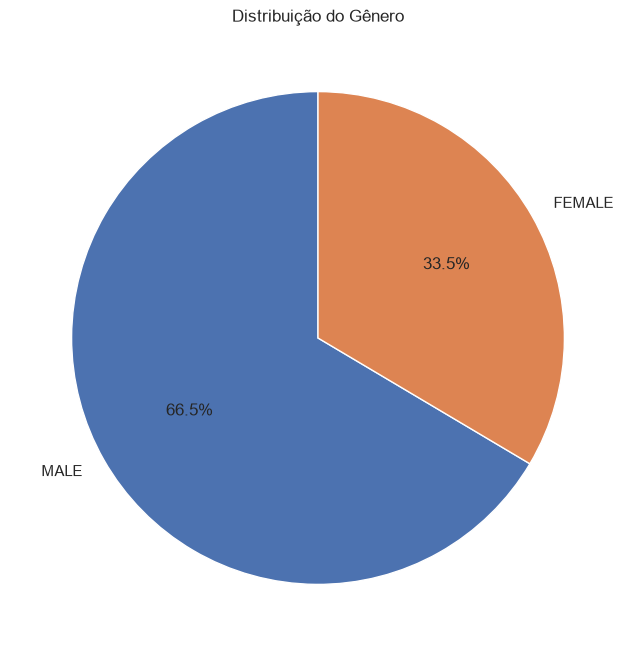

In [22]:
# Tema do Seaborn
sns.set_theme(style='whitegrid')

# Gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(
    quant_genero.values,
    labels=quant_genero.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribuição do Gênero')
plt.show()

## 4. Qual é a média de aparições dos personagens?

Vamos utilizar um histograma para verificar a distribuição dessa coluna.

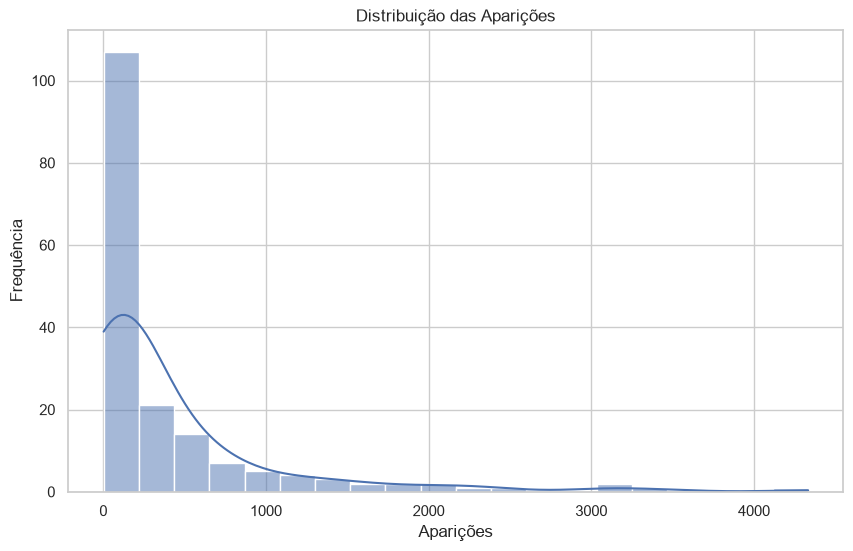

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Appearances',
    bins=20,
    kde=True
)

plt.title('Distribuição das Aparições')
plt.xlabel('Aparições')
plt.ylabel('Frequência')
plt.show()